--- Starting Water Potability Pipeline ---

📂 Upload your water potability CSV file...


Saving xgboost_updated_water_potability-updated.csv to xgboost_updated_water_potability-updated.csv

✅ Loaded → 9,154 rows × 4 columns
Columns: ['ph', 'Solids', 'Turbidity', 'Potability']

Class distribution:
Potability
0    5575
1    3579
Name: count, dtype: int64

Train: (6407, 3) | Val: (1373, 3) | Test: (1374, 3)

Missing values after impute — Train: 0, Val: 0, Test: 0

Class balance — Not Potable: 3902 | Potable: 2505 | scale_pos_weight: 1.56

Training XGBoost...
Best iteration: 499

Accuracy : 0.8042
Precision: 0.7384
Recall   : 0.7728
F1-Score : 0.7552

              precision    recall  f1-score   support

 Not Potable       0.85      0.82      0.84       837
     Potable       0.74      0.77      0.76       537

    accuracy                           0.80      1374
   macro avg       0.79      0.80      0.80      1374
weighted avg       0.81      0.80      0.80      1374

5-Fold CV F1: 0.8602 ± 0.0070



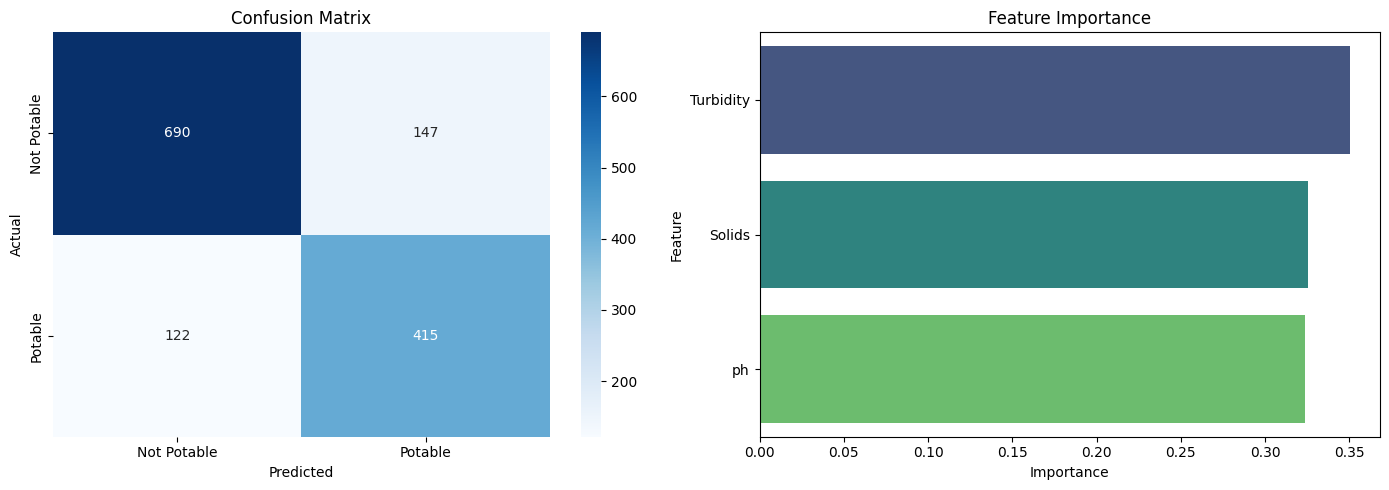


✅ CELL 1 COMPLETE — Run Cell 2 to save files


In [ ]:
# ============================================================
# XGBoost Water Potability Classifier
# CELL 1 OF 2 — Train the model
# ============================================================

!pip install xgboost scikit-learn matplotlib seaborn -q

import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.impute import SimpleImputer

np.random.seed(42)
print("--- Starting Water Potability Pipeline ---\n")

# ----------------------------------------------------------
# 1. Load Data
# ----------------------------------------------------------
from google.colab import files
print("📂 Upload your water potability CSV file...")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)
print(f"\n✅ Loaded → {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

X = df.drop('Potability', axis=1)
y = df['Potability']
print(f"\nClass distribution:\n{y.value_counts()}\n")

# ----------------------------------------------------------
# 2. Train / Val / Test Split (70 / 15 / 15)
#    Split BEFORE imputing to prevent data leakage
# ----------------------------------------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}\n")

# ----------------------------------------------------------
# 3. Impute Missing Values (fit on train only — no leakage)
# ----------------------------------------------------------
imputer = SimpleImputer(strategy='mean')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_val   = pd.DataFrame(imputer.transform(X_val),       columns=X.columns)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X.columns)
print(f"Missing values after impute — Train: {X_train.isnull().sum().sum()}, "
      f"Val: {X_val.isnull().sum().sum()}, Test: {X_test.isnull().sum().sum()}\n")

# ----------------------------------------------------------
# 4. Handle Class Imbalance
# ----------------------------------------------------------
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = neg / pos
print(f"Class balance — Not Potable: {neg} | Potable: {pos} | scale_pos_weight: {scale_pos:.2f}\n")

# ----------------------------------------------------------
# 5. Train Model
# ----------------------------------------------------------
print("Training XGBoost...")
model = xgb.XGBClassifier(
    n_estimators          = 500,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 3,
    gamma                 = 0.1,
    scale_pos_weight      = scale_pos,
    eval_metric           = 'logloss',
    early_stopping_rounds = 20,
    random_state          = 42,
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print(f"Best iteration: {model.best_iteration}\n")

# ----------------------------------------------------------
# 6. Evaluate
# ----------------------------------------------------------
y_pred = model.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Not Potable','Potable'])}")

# ----------------------------------------------------------
# 7. 5-Fold Cross-Validation
# ----------------------------------------------------------
X_full = pd.DataFrame(
    SimpleImputer(strategy='mean').fit_transform(X), columns=X.columns)
cv_model = xgb.XGBClassifier(
    n_estimators     = model.best_iteration,
    max_depth        = 6, learning_rate = 0.05,
    subsample        = 0.8, colsample_bytree = 0.8,
    min_child_weight = 3, gamma = 0.1,
    scale_pos_weight = scale_pos, eval_metric = 'logloss',
    random_state     = 42,
)
cv_scores = cross_val_score(cv_model, X_full, y, cv=5, scoring='f1')
print(f"5-Fold CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}\n")

# ----------------------------------------------------------
# 8. Confusion Matrix + Feature Importance
# ----------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Potable','Potable'],
            yticklabels=['Not Potable','Potable'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

feat_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=feat_df,
            palette='viridis', hue='Feature', legend=False, ax=axes[1])
axes[1].set_title('Feature Importance')
plt.tight_layout(); plt.show()

print("\n✅ CELL 1 COMPLETE — Run Cell 2 to save files")

In [ ]:
# ============================================================
# CELL 2 OF 2 — Save all files needed for Flask deployment
# ============================================================

import joblib
from google.colab import files

# Save model (native XGBoost format — more portable than pickle)
model.save_model('potability_xgboost.json')

# Save imputer (CRITICAL — must use same imputer that was fit on training data)
joblib.dump(imputer, 'potability_imputer.pkl')

# Save feature column names and order (CRITICAL — model expects exact order)
feature_columns = list(X.columns)
joblib.dump(feature_columns, 'potability_feature_columns.pkl')

print("✅ Saved files:")
print(f"   potability_xgboost.json          ← the trained model")
print(f"   potability_imputer.pkl           ← the fitted imputer")
print(f"   potability_feature_columns.pkl   ← {feature_columns}")
print("\n📥 Downloading all 3 files now...")

files.download('potability_xgboost.json')
files.download('potability_imputer.pkl')
files.download('potability_feature_columns.pkl')

print("\n✅ Done! You should have 3 files downloaded.")

✅ Saved files:
   potability_xgboost.json          ← the trained model
   potability_imputer.pkl           ← the fitted imputer
   potability_feature_columns.pkl   ← ['ph', 'Solids', 'Turbidity']

📥 Downloading all 3 files now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Done! You should have 3 files downloaded.
